In [ ]:
!pip install timm -q

!unzip -q fer2013.zip -d fer2013

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
import timm
import pandas as pd
import os
import glob
import random
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

Kullanılan Cihaz: cpu


In [ ]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = 'fer2013'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'test']}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=128, shuffle=True) for x in ['train', 'test']}

In [ ]:
model = timm.create_model('regnetx_002', pretrained=True, num_classes=7)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001) 
imdb_df = pd.read_csv('imdb_top_1000.csv')

emotion_to_genre = {0: "Angry", 1: "Disgust", 2: "Fear", 3: "Happy", 4: "Sad", 5: "Surprise", 6: "Neutral"}
genre_mapping = {
    "Angry": "Action", "Disgust": "Thriller", "Fear": "Horror",
    "Happy": "Comedy", "Sad": "Drama", "Surprise": "Sci-Fi", "Neutral": "Romance"
}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/10.8M [00:00<?, ?B/s]

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 20)

        for phase in ['train', 'test']:
            if phase == 'train': model.train()
            else: model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])

            print(f'{phase.upper()} -> Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print()
    return model

model = train_model(model, criterion, optimizer, num_epochs=10)

Epoch 1/10
--------------------
TRAIN -> Loss: 1.1960 Acc: 0.5445
TEST -> Loss: 1.0700 Acc: 0.5953

Epoch 2/10
--------------------
TRAIN -> Loss: 0.9632 Acc: 0.6416
TEST -> Loss: 1.0102 Acc: 0.6218

Epoch 3/10
--------------------
TRAIN -> Loss: 0.8590 Acc: 0.6769
TEST -> Loss: 1.0334 Acc: 0.6173

Epoch 4/10
--------------------
TRAIN -> Loss: 0.7802 Acc: 0.7098
TEST -> Loss: 1.0179 Acc: 0.6291

Epoch 5/10
--------------------
TRAIN -> Loss: 0.7058 Acc: 0.7397
TEST -> Loss: 1.0128 Acc: 0.6390

Epoch 6/10
--------------------
TRAIN -> Loss: 0.6412 Acc: 0.7656
TEST -> Loss: 1.0402 Acc: 0.6385

Epoch 7/10
--------------------
TRAIN -> Loss: 0.5725 Acc: 0.7902
TEST -> Loss: 1.0917 Acc: 0.6425

Epoch 8/10
--------------------
TRAIN -> Loss: 0.5184 Acc: 0.8112
TEST -> Loss: 1.0946 Acc: 0.6432

Epoch 9/10
--------------------
TRAIN -> Loss: 0.4725 Acc: 0.8285
TEST -> Loss: 1.2194 Acc: 0.6484

Epoch 10/10
--------------------
TRAIN -> Loss: 0.4206 Acc: 0.8511
TEST -> Loss: 1.2099 Acc: 0.6474


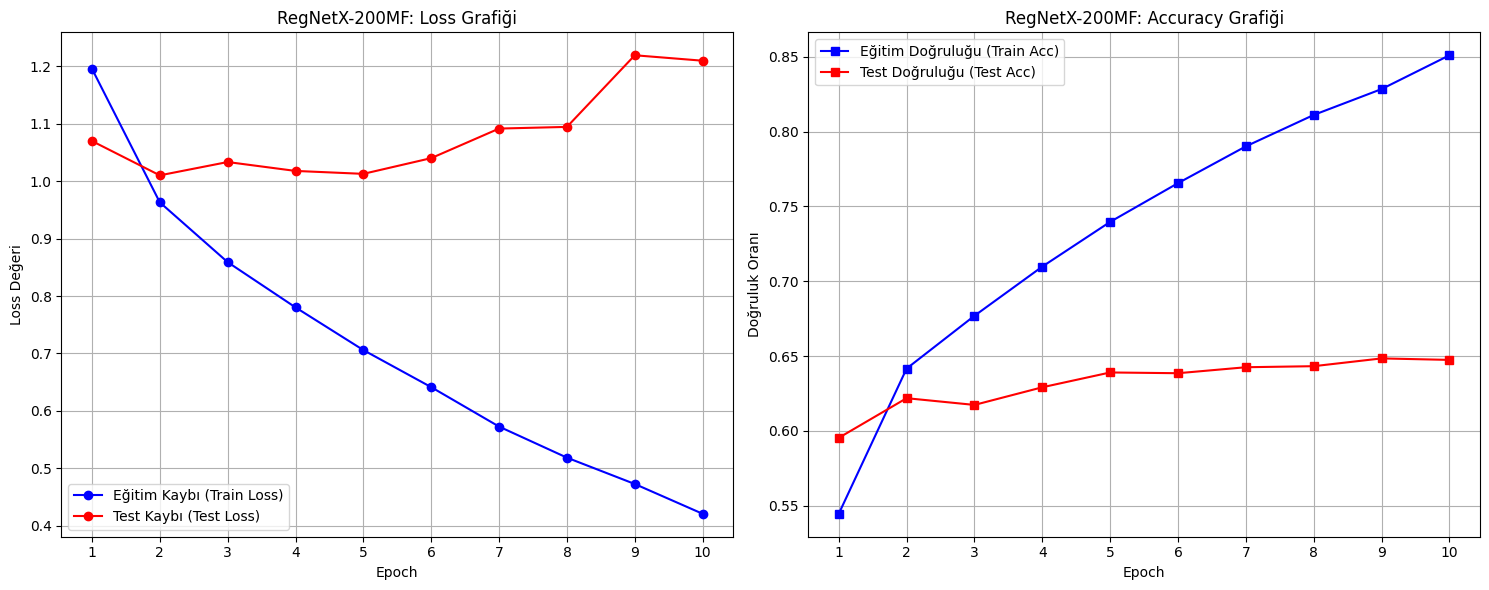

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))

train_loss = [1.1960, 0.9632, 0.8590, 0.7802, 0.7058, 0.6412, 0.5725, 0.5184, 0.4725, 0.4206]
test_loss = [1.0700, 1.0102, 1.0334, 1.0179, 1.0128, 1.0402, 1.0917, 1.0946, 1.2194, 1.2099]

train_acc = [0.5445, 0.6416, 0.6769, 0.7098, 0.7397, 0.7656, 0.7902, 0.8112, 0.8285, 0.8511]
test_acc = [0.5953, 0.6218, 0.6173, 0.6291, 0.6390, 0.6385, 0.6425, 0.6432, 0.6484, 0.6474]

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, 'b-o', label='Eğitim Kaybı (Train Loss)')
plt.plot(epochs, test_loss, 'r-o', label='Test Kaybı (Test Loss)')
plt.title('RegNetX-200MF: Loss Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Loss Değeri')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, 'b-s', label='Eğitim Doğruluğu (Train Acc)')
plt.plot(epochs, test_acc, 'r-s', label='Test Doğruluğu (Test Acc)')
plt.title('RegNetX-200MF: Accuracy Grafiği')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk Oranı')
plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('egitim_sonuclari.png') 
plt.show()

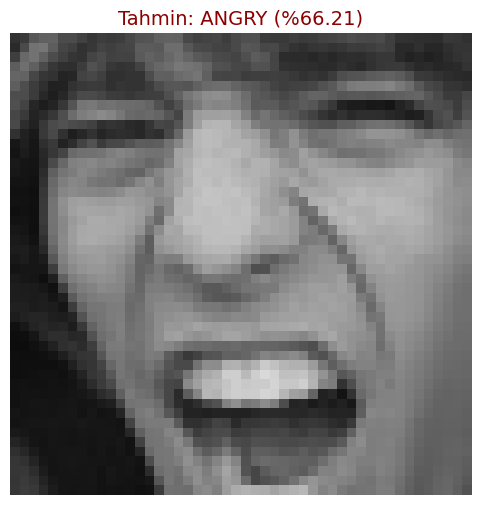


ANALİZ EDİLEN: PublicTest_94047538.jpg
DUYGU: ANGRY (%66.21)
ÖNERİLEN FİLM: X: First Class (Action)
IMDB PUANI: 7.7
ÖZET: In the 1960s, superpowered humans Charles Xavier and Erik Lensherr work together to find others like them, but Erik's vengeful pursuit of an ambitious...


In [ ]:
import matplotlib.pyplot as plt

def predict_and_recommend(image_path, model, imdb_df):
    img = Image.open(image_path).convert('RGB')

    img_t = data_transforms['test'](img).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        output = model(img_t)
        probs = F.softmax(output, dim=1)
        conf, pred = torch.max(probs, 1)
        emotion_idx = pred.item()

    target_genre = genre_mapping[emotion_to_genre[emotion_idx]]
    filtered = imdb_df[imdb_df['Genre'].str.contains(target_genre, case=False)]
    movie = filtered.sample(n=1).iloc[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(f"Tahmin: {emotion_to_genre[emotion_idx].upper()} (%{conf.item()*100:.2f})", fontsize=14, color='darkred')
    plt.axis('off') 
    plt.show()

    print("\n" + "="*45)
    print(f"ANALİZ EDİLEN: {os.path.basename(image_path)}")
    print(f"DUYGU: {emotion_to_genre[emotion_idx].upper()} (%{conf.item()*100:.2f})")
    print(f"ÖNERİLEN FİLM: {movie['Series_Title']} ({target_genre})")
    print(f"IMDB PUANI: {movie['IMDB_Rating']}")
    print(f"ÖZET: {movie['Overview'][:150]}...")
    print("="*45)

test_imgs = glob.glob("fer2013/test/**/*.*", recursive=True)
if test_imgs:
    predict_and_recommend(random.choice(test_imgs), model, imdb_df)

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []
y_score = []

model.eval()
with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs)

        probs = F.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_score.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_score = np.array(y_score)
target_names = list(emotion_to_genre.values())

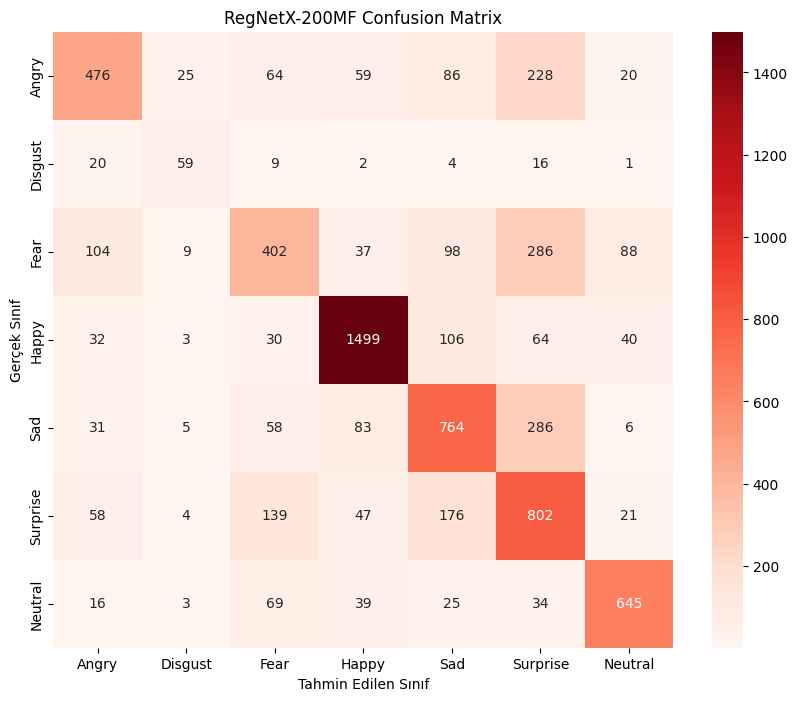

In [ ]:
def plot_confusion_matrix(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=labels, yticklabels=labels)
    plt.title('RegNetX-200MF Confusion Matrix')
    plt.ylabel('Gerçek Sınıf')
    plt.xlabel('Tahmin Edilen Sınıf')
    plt.show()

plot_confusion_matrix(y_true, y_pred, target_names)

In [12]:
print("="*60)
print("SINIF BAZLI PERFORMANS RAPORU")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_names))

SINIF BAZLI PERFORMANS RAPORU
              precision    recall  f1-score   support

       Angry       0.65      0.50      0.56       958
     Disgust       0.55      0.53      0.54       111
        Fear       0.52      0.39      0.45      1024
       Happy       0.85      0.84      0.85      1774
         Sad       0.61      0.62      0.61      1233
    Surprise       0.47      0.64      0.54      1247
     Neutral       0.79      0.78      0.78       831

    accuracy                           0.65      7178
   macro avg       0.63      0.61      0.62      7178
weighted avg       0.66      0.65      0.65      7178



/tmp/ipython-input-915828616.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))


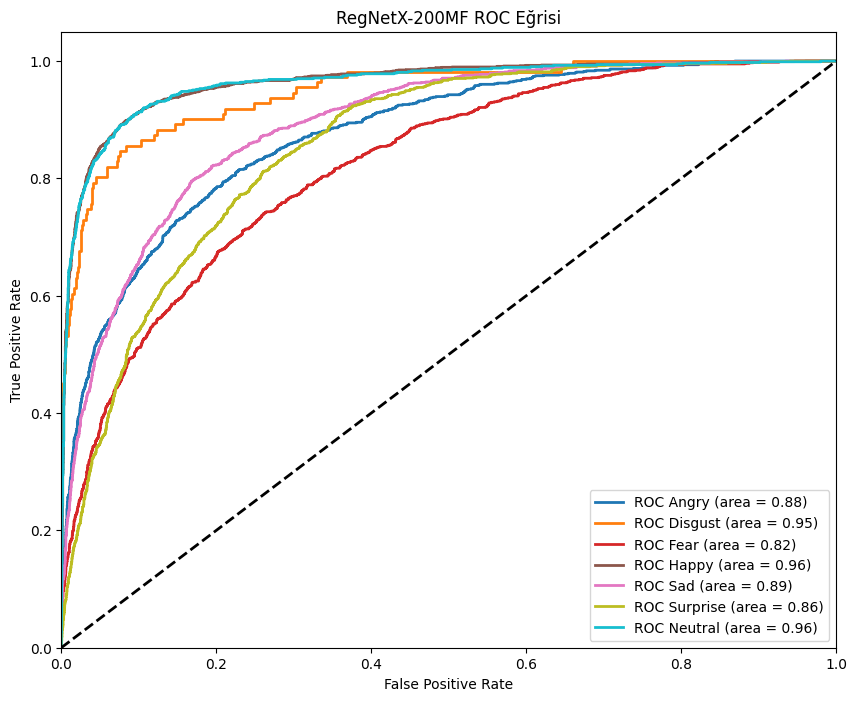

In [ ]:
def plot_roc_curve(y_true, y_score, n_classes, labels):
    y_true_bin = label_binarize(y_true, classes=range(n_classes))

    plt.figure(figsize=(10, 8))
    colors = plt.cm.get_cmap('tab10')(np.linspace(0, 1, n_classes))

    for i, color in zip(range(n_classes), colors):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, color=color, lw=2,
                 label=f'ROC {labels[i]} (area = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('RegNetX-200MF ROC Eğrisi')
    plt.legend(loc="lower right")
    plt.show()

plot_roc_curve(y_true, y_score, len(target_names), target_names)